# Lab 6 Neural Networks

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9736842105263158


E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [3]:
# # make_pipeline A pipeline is just a recipe:
# “do this → then this → then this → then predict”
model = make_pipeline(StandardScaler(),
                      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200))

model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9736842105263158


In [4]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9736842105263158


# Keras

Epoch 1/30


E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7143 - loss: 0.5979 - mse: 0.2067 - val_accuracy: 0.8022 - val_loss: 0.5368 - val_mse: 0.1794
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8901 - loss: 0.4672 - mse: 0.1492 - val_accuracy: 0.9231 - val_loss: 0.4325 - val_mse: 0.1342
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9258 - loss: 0.3619 - mse: 0.1062 - val_accuracy: 0.9231 - val_loss: 0.3460 - val_mse: 0.0994
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9505 - loss: 0.2805 - mse: 0.0763 - val_accuracy: 0.9231 - val_loss: 0.2710 - val_mse: 0.0730
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9560 - loss: 0.2153 - mse: 0.0551 - val_accuracy: 0.9231 - val_loss: 0.2157 - val_mse: 0.0572
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9698 - loss: 0.1690 - mse: 0.0417 - val_accuracy: 0.9341 - val_loss: 0.1827 - val_mse: 0.0491
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accu

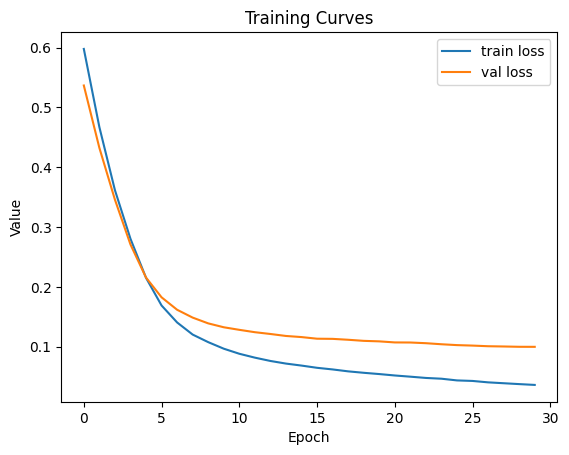

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Model 
model = keras.Sequential([layers.Dense(32, activation='relu', input_shape=(X.shape[1],)),
                          layers.Dense(16, activation='relu'),
                          layers.Dense(1, activation='sigmoid')])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', 'mse'])

# Training
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=5,
                                           restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=1)

# Evaluation
loss, acc, mse = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", acc)
print("Test MSE:", mse)

# Confusion Matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot Training Curves
plt.figure()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curves")
plt.legend()
plt.show()


Running Grid Search...



E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

Best Parameters: {'batch_size': 16, 'epochs': 10, 'model__units1': 32, 'model__units2': 8}
Best Score: 0.9648251423260138
Epoch 1/30


E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8297 - loss: 0.5518 - mse: 0.1835 - val_accuracy: 0.9670 - val_loss: 0.4343 - val_mse: 0.1325
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9368 - loss: 0.3721 - mse: 0.1087 - val_accuracy: 0.9780 - val_loss: 0.3018 - val_mse: 0.0828
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9643 - loss: 0.2448 - mse: 0.0627 - val_accuracy: 0.9780 - val_loss: 0.2053 - val_mse: 0.0534
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9725 - loss: 0.1639 - mse: 0.0387 - val_accuracy: 0.9780 - val_loss: 0.1566 - val_mse: 0.0398
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.1254 - mse: 0.0289 - val_accuracy: 0.9780 - val_loss: 0.1300 - val_mse: 0.0333
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.1016 - mse: 0.0230 - val_accuracy: 0.9780 - val_loss: 0.1168 - val_mse: 0.0300
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 

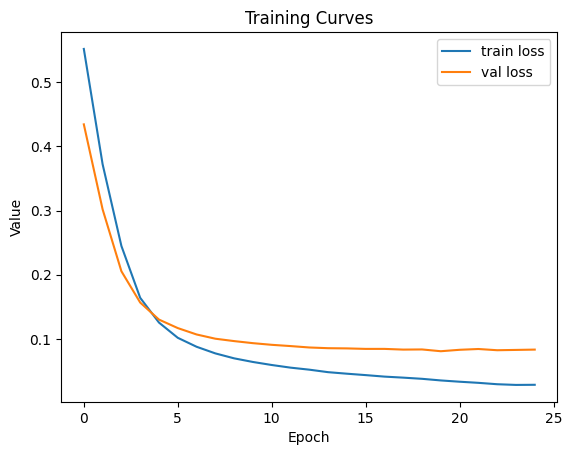

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasClassifier

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def create_model(units1=32, units2=16):
    model = keras.Sequential([layers.Dense(units1, activation='relu', input_shape=(X.shape[1],)),
                              layers.Dense(units2, activation='relu'),
                              layers.Dense(1, activation='sigmoid') ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'mse'])
    return model
print("\nRunning Grid Search...\n")

keras_model = KerasClassifier(model=create_model, verbose=0)

param_grid = {"model__units1": [16, 32],
              "model__units2": [8, 16],
              "epochs": [10],
              "batch_size": [16, 32]}

grid = GridSearchCV(keras_model, param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_params = grid.best_params_

final_model = create_model(units1=best_params["model__units1"],
                           units2=best_params["model__units2"])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=5,
                                           restore_best_weights=True)

history = final_model.fit(X_train, y_train,
                          epochs=30,
                          batch_size=best_params["batch_size"],
                          validation_split=0.2,
                          callbacks=[early_stop],
                          verbose=1)

loss, acc, mse = final_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)
print("Test MSE:", mse)

y_pred = (final_model.predict(X_test) > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curves")
plt.legend()
plt.show()

## MNIST dataset
- Large database of handwritten digits that is commonly used for training various image processing systems.
- consisting of 70,000 pixel grayscale images of handwritten digits (0-9).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

# ======================
# Load MNIST dataset
# ======================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [8]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

Epoch 1/10


E:\Programms Files\Anaconda\anaconda\envs\tf312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9213 - loss: 0.2682 - val_accuracy: 0.9615 - val_loss: 0.1303
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9668 - loss: 0.1093 - val_accuracy: 0.9651 - val_loss: 0.1100
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0754 - val_accuracy: 0.9703 - val_loss: 0.0923
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9816 - loss: 0.0579 - val_accuracy: 0.9716 - val_loss: 0.0961
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9746 - val_loss: 0.0937
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9699 - val_loss: 0.1085
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9900 - loss: 0.0291 - val_accuracy: 0.9747 - val_loss: 0.0970
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accurac

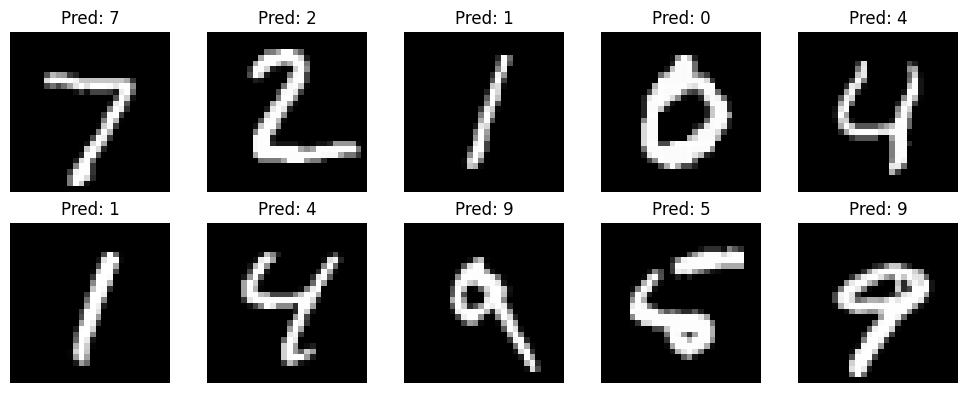

In [9]:


# Normalize images

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# Flatten images (28x28 → 784)

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)


# Build Neural Network

model = keras.Sequential([layers.Dense(128, activation='relu', input_shape=(784,)),
                          layers.Dense(64, activation='relu'),
                          layers.Dense(10, activation='softmax')])

# Compile model -- set up how the model learns

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

# Predictions
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)

# Show some predictions
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()



# PyTorch

Epoch 1: train_loss=0.6996, val_loss=0.6349
Epoch 2: train_loss=0.6314, val_loss=0.5738
Epoch 3: train_loss=0.5690, val_loss=0.5096
Epoch 4: train_loss=0.5045, val_loss=0.4420
Epoch 5: train_loss=0.4380, val_loss=0.3772
Epoch 6: train_loss=0.3747, val_loss=0.3200
Epoch 7: train_loss=0.3187, val_loss=0.2727
Epoch 8: train_loss=0.2726, val_loss=0.2349
Epoch 9: train_loss=0.2362, val_loss=0.2043
Epoch 10: train_loss=0.2073, val_loss=0.1787
Epoch 11: train_loss=0.1838, val_loss=0.1561
Epoch 12: train_loss=0.1643, val_loss=0.1355
Epoch 13: train_loss=0.1478, val_loss=0.1170
Epoch 14: train_loss=0.1337, val_loss=0.1008
Epoch 15: train_loss=0.1217, val_loss=0.0875
Epoch 16: train_loss=0.1112, val_loss=0.0773
Epoch 17: train_loss=0.1020, val_loss=0.0702
Epoch 18: train_loss=0.0944, val_loss=0.0653
Epoch 19: train_loss=0.0881, val_loss=0.0621
Epoch 20: train_loss=0.0829, val_loss=0.0602
Epoch 21: train_loss=0.0787, val_loss=0.0592
Epoch 22: train_loss=0.0755, val_loss=0.0588
Epoch 23: train_los

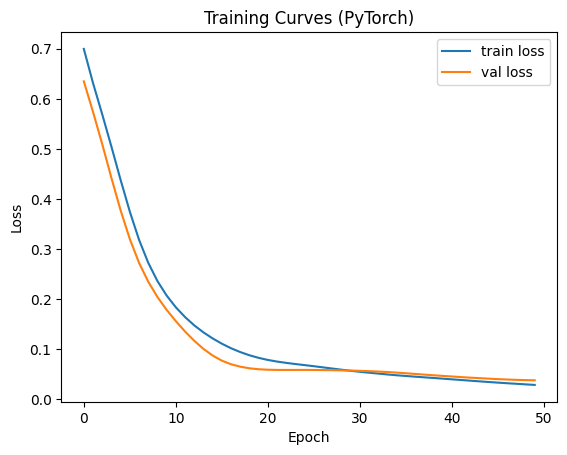

In [15]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Model
class MLP(nn.Module):
    def __init__(self, input_dim, units1=32, units2=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, units1),
                                 nn.ReLU(),
                                 nn.Linear(units1, units2),
                                 nn.ReLU(),
                                 nn.Linear(units2, 1),
                                 nn.Sigmoid())

    def forward(self, x):
        return self.net(x)

model = MLP(X.shape[1])

# Loss + Optimizer

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop (with early stopping)

epochs = 50
patience = 5

train_losses = []
val_losses = []

best_val_loss = float("inf")
counter = 0

val_split = int(0.2 * len(X_train))

X_val = X_train[:val_split]
y_val = y_train[:val_split]
X_tr = X_train[val_split:]
y_tr = y_train[val_split:]

for epoch in range(epochs):

    # ---- train ----
    model.train()
    preds = model(X_tr)
    loss = loss_fn(preds, y_tr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ---- validation ----
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = loss_fn(val_preds, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    print(f"Epoch {epoch+1}: train_loss={loss.item():.4f}, val_loss={val_loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    test_preds = model(X_test)
    test_preds_binary = (test_preds > 0.5).int()

cm = confusion_matrix(y_test.numpy(), test_preds_binary.numpy())

print("\nConfusion Matrix:\n", cm)

# Plot loss curves

plt.figure()
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curves (PyTorch)")
plt.legend()
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin


data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42)

class MLP(nn.Module):
    def __init__(self, input_dim, units1=32, units2=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, units1),
                                 nn.ReLU(),
                                 nn.Linear(units1, units2),
                                 nn.ReLU(),
                                 nn.Linear(units2, 1),
                                 nn.Sigmoid())

    def forward(self, x):
        return self.net(x)
        
class TorchMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, units1=32, units2=16, epochs=20, lr=0.001):
        self.units1 = units1
        self.units2 = units2
        self.epochs = epochs
        self.lr = lr

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

        self.model = MLP(X.shape[1], self.units1, self.units2)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.BCELoss()

        for _ in range(self.epochs):
            pred = self.model(X)
            loss = loss_fn(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        return self

    def predict(self, X):
        X = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            preds = self.model(X)
        return (preds > 0.5).int().numpy().flatten()

print("\nRunning Grid Search...\n")

param_grid = {"units1": [16, 32],
              "units2": [8, 16],
              "epochs": [10, 20],
              "lr": [0.001, 0.01]}

grid = GridSearchCV(TorchMLP(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

best = grid.best_params_

final_model = TorchMLP(units1=best["units1"],
                       units2=best["units2"],
                       epochs=best["epochs"],
                       lr=best["lr"])

final_model.fit(X_train, y_train)


preds = final_model.predict(X_test)

print("Confusion Matrix:\n",
      confusion_matrix(y_test, preds))


Running Grid Search...

Best Params: {'epochs': 20, 'lr': 0.01, 'units1': 32, 'units2': 8}
Best Score: 0.9692256303009179
Confusion Matrix:
 [[42  1]
 [ 2 69]]


# Regression

Final Training Loss: 0.3557787239551544
Final Validation Loss: 0.37653231620788574
Test MSE: 0.34626346826553345
Test R²: 0.7381375432014465


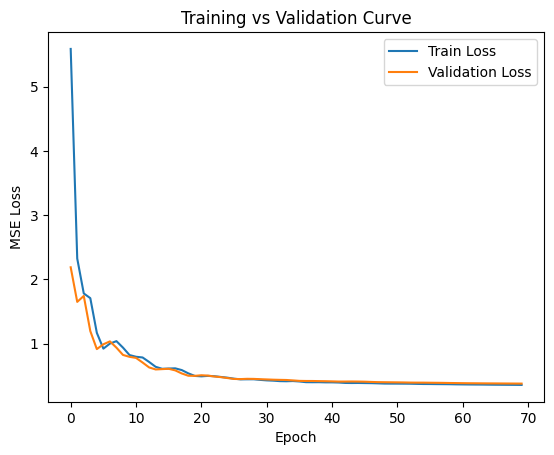

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

data = fetch_california_housing()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert to tensors
def to_tensor(x, y):
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X_train, y_train = to_tensor(X_train, y_train)
X_val, y_val = to_tensor(X_val, y_val)
X_test, y_test = to_tensor(X_test, y_test)


# Model
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


model = RegressionNet(X.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

# Training loop
for epoch in range(70):
    # Train
    model.train()
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = loss_fn(val_pred, y_val)

    val_losses.append(val_loss.item())

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])


# Evaluation
model.eval()
with torch.no_grad():
    preds = model(X_test).numpy()

mse = mean_squared_error(y_test.numpy(), preds)
r2 = r2_score(y_test.numpy(), preds)

print("Test MSE:", mse)
print("Test R²:", r2)


# Plot curves
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Curve")
plt.legend()
plt.show()

Training done. Final loss: 0.3665154278278351
Test MSE (before saving): 0.37708404660224915
Model saved.
Model loaded.
Test MSE (after loading): 0.37708404660224915


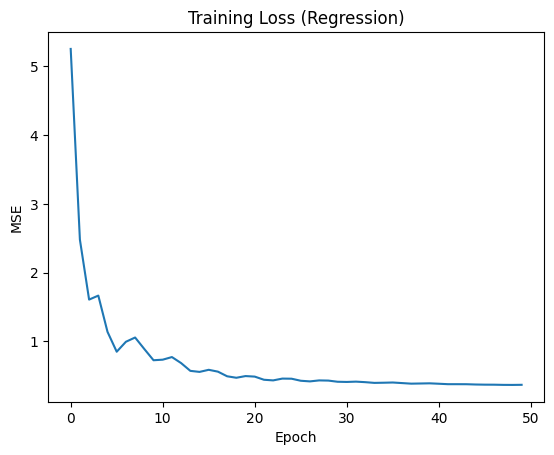

In [18]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


data = fetch_california_housing()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


# Model
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 32),
                                 nn.ReLU(),
                                 nn.Linear(32, 1))

    def forward(self, x):
        return self.net(x)

model = RegressionNet(X.shape[1])

# Train
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

losses = []

for epoch in range(50):
    model.train()

    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Training done. Final loss:", losses[-1])

# Test BEFORE saving
model.eval()
with torch.no_grad():
    preds = model(X_test).numpy()

mse_before = mean_squared_error(y_test.numpy(), preds)
print("Test MSE (before saving):", mse_before)

# Save model
torch.save(model.state_dict(), "regression_model.pth")
print("Model saved.")

# Load model
loaded_model = RegressionNet(X.shape[1])
loaded_model.load_state_dict(torch.load("regression_model.pth"))
loaded_model.eval()

print("Model loaded.")

# Test AFTER loading
with torch.no_grad():
    loaded_preds = loaded_model(X_test).numpy()

mse_after = mean_squared_error(y_test.numpy(), loaded_preds)

print("Test MSE (after loading):", mse_after)

# Plot training curve
plt.plot(losses)
plt.title("Training Loss (Regression)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [19]:
import numpy as np
import torch
import torch.nn as nn
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = fetch_california_housing()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

# SAVE SCALER 

joblib.dump(scaler, "scaler.pkl")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# =========================
# 4. Model
# =========================
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


model = RegressionNet(X.shape[1])

#  Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

for epoch in range(50):
    model.train()

    preds = model(X_train)
    loss = loss_fn(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# SAVE MODEL
torch.save(model.state_dict(), "regression_model.pth")
print("Model + scaler saved.")

Epoch 0, Loss: 6.3576
Epoch 10, Loss: 0.7338
Epoch 20, Loss: 0.5049
Epoch 30, Loss: 0.4289
Epoch 40, Loss: 0.3907
Model + scaler saved.
